# exp08 pre-design forensics - the five checks that gate the next experiment

`exp07_diagnostics.ipynb` **reports** exp07. This notebook **checks what exp07 left standing** before
exp08 is designed. Five checks, from the handoff `tmp/checks_before_exp08.md`, grilled and sharpened
2026-08-06. All zero-training: every number here comes from a checkpoint, a cache or a curve dump that
already exists.

| # | Check | Open question | What it decides |
|---|---|---|---|
| **CHK-1** | 7-probe downstream menu on the frozen recipe | Q1 | the exp08 branch, and whether the ML4PS tables can keep quoting exp05-arm transfer numbers |
| **CHK-2** | the centre-of-window artifact the taper created | (new) | whether the reconstruction defect is exp08's problem or paper hygiene |
| **CHK-3** | what channel the probes actually read | Q2 | whether any aux/geometry lever can move the probes at all |
| **CHK-4** | what the dynamics arm's extra active units carry | Q11 | the mechanism sentence for the paper's central result |
| **CHK-5** | the checkpoint-selection guard | Q8 | (resolved before the run: see section 1) |

**Pre-registration.** Fixed before any number below was read:

- **Gate 0 (transfer, primary).** `hann0p3_fbwd` vs untrained on `numax_hon` R2. PASS if delta > 2*SE_diff.
- **Gate 1 (taper cost, primary).** paired `hann0p3 - comb0p3`, fbwd arm, `numax_hon` R2. FAIL if delta < -2*SE_paired.
- Primary probe is `numax_hon` because it reads 65-260 microHz directly - the band F19 measured the
  taper degrading by 13% - and an R2 carries no base-rate pathology. `osc_giant`, `solar_like_osc`,
  `rgb_vs_heb` replicate; they are not independent gates.
- **`fbwd` decides** (it is the frozen recipe); `off` replicates and is never pooled with it (F21).
- Branch rule: Gate 0 fails -> exp08 is neither branch A nor B, the objective class is the lever.
  Gate 0 passes and Gate 1 fails -> branch A (Q12, frequency-weighted / multitaper aux). Both pass ->
  branch B. **If CHK-3 says mu is a re-encoding of the engineered basis, CHK-3 outranks CHK-1**: Gate 1
  only says which aux term is least bad, CHK-3 says whether any aux term can move the probes.

**Standing traps this notebook is written against.** Paired by seed. Absolute score, never the
trained-minus-untrained gap, as the selection quantity (F4). Never pool across the dynamics arm (F21).
A window comparison needs a referee neither arm trained against (F19). Both sides' seed spread enters
every SE (F17).

Produced by `experiments/run_exp08_prechecks.ps1`. Re-run that first if any input below is missing.

In [1]:
# --- parameters -------------------------------------------------------------------------------
frozen_recipe = "hann0p3"       # exp07 winner, the frozen base recipe
baseline_recipe = "comb0p3"     # its paired untapered baseline
wide_recipe = "lpsd0p3"         # the 18-active-unit arm, carried to close Q3 on the downstream menu
deciding_arm = "fbwd"           # the frozen recipe's arm; `off` replicates and is never pooled with it
primary_probe = "numax_hon"     # pre-registered primary; reads 65-260 microHz, the band the taper costs
replication = ["osc_giant", "solar_like_osc", "rgb_vs_heb"]
adr0010_menu = ["numax_hon", "rotation_period", "osc_giant", "solar_like_osc", "rgb_vs_heb",
                "ijspeert", "flare"]
seeds = [0, 1, 2, 3, 4, 5]

In [2]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
warnings.filterwarnings("ignore")

root = Path(r"C:\git_repo\Stellar-World-Model")
sys.path.insert(0, str(root / "src"))
exps = root / "experiments"
prechecks = exps / "exp08_prechecks"

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

required = {
    "gates":        prechecks / "gates.csv",
    "menu":         prechecks / "menu.csv",
    "scorecard":    prechecks / "new_task_scorecard.csv",
    "ceiling":      prechecks / "ceiling_A1A2.csv",
    "centre_cells": exps / "exp07_centre_cells.csv",
    "centre_stars": exps / "exp07_centre_stars.csv",
    "centre_probe": exps / "exp07_centre_summary.csv",
    "stitch":       exps / "exp07_stitch_spectrum_summary.csv",
    "channel":      exps / "exp07_channel_probe.csv",
    "featmap":      exps / "exp07_channel_feature_map.csv",
    "cca":          exps / "exp07_dynunits_cca.csv",
    "residual":     exps / "exp07_dynunits_residual.csv",
    "scaling":      exps / "exp07_dynunits_scaling.csv",
    "profiles":     exps / "exp07_edge_profiles_6seed.parquet",
    "aux_gap":      exps / "exp07_aux_gap.csv",   # v1 probe scores for all TEN exp07 cells
    "edge_noise_stars": exps / "exp07_edge_noise_stars.csv",  # per-star noise/amp, for the 3.3 control
}
missing = {k: p for k, p in required.items() if not p.exists()}
assert not missing, ("run experiments/run_exp08_prechecks.ps1 first; missing:\n  "
                     + "\n  ".join(f"{k}: {p}" for k, p in missing.items()))
print(f"all {len(required)} required inputs present")

all 16 required inputs present


---
## 1. CHK-5 - F18 is retracted: the selection bug never existed

F18 reported that `best_recon_aux` selects the pre-warmup **epoch-0** checkpoint at aux weight 0.1 with
dynamics off - "128 active units, sitting at the untrained floor while wearing a trained label" - and
open question Q8 turned that into a standing rule that any experiment lowering `recon_aux.weight` must
first land a warmup floor in the selector.

The training loop has always had that floor. `src/swm/train/loop.py`:

```python
improved_select = track_select and epoch >= warmup and val_select < best_select
```

and `beta_warmup_epochs = 10` in every exp07 checkpoint's stored config. The cell below reads the epoch
out of the saved checkpoints and out of the curve dumps, which is what separates the two readings.

In [3]:
# 1.1 - what the saved checkpoints actually selected, vs what a curve argmin claims they selected
import torch

rows = []
for cell in ["exp07_comb0p1_off", "exp07_lpsd0p1_off", "exp07_hann0p3_off", "exp07_hann0p3_fbwd"]:
    for seed in range(4):
        ckpt_path = exps / cell / "models" / f"B_seed{seed}" / "best_recon_aux.pt"
        curve_path = exps / "exp07_forensics" / "curves_exp07" / f"{cell}_B_seed{seed}.csv"
        if not ckpt_path.exists():
            continue
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        row = {"cell": cell, "seed": seed, "ckpt_epoch": int(ckpt["epoch"]),
               "warmup": int(ckpt["cfg"]["train"]["beta_warmup_epochs"])}
        if curve_path.exists():
            curve = pd.read_csv(curve_path).dropna(subset=["val/monitor_recon_aux"])
            # F22: the exp07 dump lost the pre-resume epochs of the two runs the sweep runner resumed
            # (comb0p3_off s2, hann0p3_fbwd s3). Their curves begin at epoch 30/37, so an argmin over
            # "all epochs" cannot see epoch 0 and the comparison below is meaningless for them. Flag and
            # skip the curve-derived columns rather than assert -- the checkpoint column is still valid.
            row["prefix_lost"] = bool(curve["epoch"].min() != 0)
            if row["prefix_lost"]:
                rows.append(row)
                continue
            row["argmin_all_epochs"] = int(curve.loc[curve["val/monitor_recon_aux"].idxmin(), "epoch"])
            post = curve[curve["epoch"] >= row["warmup"]]
            row["argmin_post_warmup"] = int(post.loc[post["val/monitor_recon_aux"].idxmin(), "epoch"])
            row["n_active_ep0"] = int(curve.loc[curve["epoch"] == 0, "val/n_active_units"].iloc[0])
            sel = curve[curve["epoch"] == row["ckpt_epoch"]]
            row["n_active_at_ckpt"] = int(sel["val/n_active_units"].iloc[0]) if len(sel) else np.nan
        rows.append(row)

f18 = pd.DataFrame(rows)
display(f18)
print("\nany saved checkpoint inside the warmup?",
      bool((f18["ckpt_epoch"] < f18["warmup"]).any()))
usable = f18[~f18["prefix_lost"].fillna(False)]
print("curve argmin lands on epoch 0 for:",
      sorted(usable.loc[usable["argmin_all_epochs"] == 0, "cell"].unique()))
print("runs excluded for a lost pre-resume prefix (F22):",
      f18.loc[f18["prefix_lost"].fillna(False), ["cell", "seed"]].to_dict("records"))

,cell,seed,ckpt_epoch,warmup,prefix_lost,argmin_all_epochs,argmin_post_warmup,n_active_ep0,n_active_at_ckpt
0,exp07_comb0p1_off,0,98,10,False,0.0,98.0,128.0,5.0
1,exp07_comb0p1_off,1,97,10,False,0.0,97.0,128.0,6.0
2,exp07_comb0p1_off,2,98,10,False,0.0,98.0,128.0,5.0
3,exp07_comb0p1_off,3,98,10,False,0.0,98.0,128.0,5.0
4,exp07_lpsd0p1_off,0,86,10,False,0.0,86.0,128.0,5.0
5,exp07_lpsd0p1_off,1,91,10,False,0.0,91.0,128.0,6.0
6,exp07_lpsd0p1_off,2,99,10,False,0.0,99.0,128.0,6.0
7,exp07_lpsd0p1_off,3,85,10,False,0.0,85.0,128.0,5.0
8,exp07_hann0p3_off,0,49,10,False,49.0,49.0,128.0,6.0
9,exp07_hann0p3_off,1,40,10,False,40.0,40.0,128.0,4.0



any saved checkpoint inside the warmup? False
curve argmin lands on epoch 0 for: ['exp07_comb0p1_off', 'exp07_lpsd0p1_off']
runs excluded for a lost pre-resume prefix (F22): [{'cell': 'exp07_hann0p3_fbwd', 'seed': 3}]


#### 1.1 - the artifact was in the analysis, not in the selector

Every saved `best_recon_aux.pt` sits at an epoch well past the warmup, with a **collapsed** latent
(5-6 active units), while the unrestricted argmin over the logged history lands on epoch 0 with **128**
active units. Notebook A6/A6b computed the second and reported it as the first.

**What survives.** The observation that the weight-0.1 dyn-off cells score near the untrained floor
(+0.003 / +0.012) is a real measurement and is unaffected. Its *cause* is now unknown: it is not
epoch-0 selection. Since those cells are two steps from the frozen recipe, this is flagged and not
chased before the Aug 15 freeze.

**What changes.** F18 is retracted and rewritten as a method finding of a more general kind - a
post-hoc statistic that reconstructs a selection decision must reproduce the selector's own
constraints, or be checked against the saved artifact. That is the same family as F14 (the epoch-0 row
misleads a human reader) and F22 (align curves on the `epoch` column). Q8 closes. The only code change
CHK-5 warrants is the regression test now pinning the guard
(`test_dual_checkpoint.py::test_select_never_picks_a_warmup_epoch`).

In [4]:
# 1.2 - the exclusion audit: was any exp07 table narrowed on F18's (now retracted) grounds?
readme = (exps / "exp07_aux_README.md").read_text(encoding="utf-8", errors="replace")
hits = [line.strip() for line in readme.splitlines()
        if any(tag in line for tag in ["F18", "epoch-0", "epoch 0", "0p1_off", "weight 0.1"])]
print(f"{len(hits)} line(s) in exp07_aux_README.md reference the retracted mechanism:\n")
for line in hits:
    print("  " + line[:160])

5 line(s) in exp07_aux_README.md reference the retracted mechanism:

  1. **Two cells never selected a trained checkpoint (notebook A6).** `comb0p1_off` and `lpsd0p1_off` pick
  **epoch 0** on all four seeds, with 128 active units and `mu_var` ≈ 22 at the selected step. The cause
  is the selection metric: `best_recon_aux` minimises `recon + w·aux`, and at weight 0.1 the weighted aux
  reconstruction penalty the KL warmup imposes (0.77 → 0.88, i.e. +0.10), so the pre-collapse epoch-0
  the same caveat. Recorded as F18.


---
## 2. CHK-1 - the downstream menu on the frozen recipe

Two gates, both pre-registered above. Gate 1 is the taper cost the handoff asked about. Gate 0 is the
question the caches also answer and nobody had asked: **every** asteroseismic number in this project
(`numax_hon` R2 +0.286, `osc_giant` +0.098, `solar_like_osc`, `rgb_vs_heb`) was measured on **exp05**
arms - a different recipe at a 60-epoch budget - and F25(a) shows a short-budget run is not a prefix of
a long one. The frozen recipe has never been scored on this menu at all.

The untrained reference carries **six random inits** here rather than the historical single seed-0 one,
so its own spread enters every SE instead of the zero F17 warns about.

In [5]:
# 2.1 - the two pre-registered gates on the primary probe
gates = pd.read_csv(required["gates"])
menu = pd.read_csv(required["menu"])

g0 = gates[(gates.task == primary_probe) & (gates.recipe == frozen_recipe) & (gates.arm == deciding_arm)]
g1 = gates[(gates.task == primary_probe) & (gates.recipe == f"{frozen_recipe}_minus_{baseline_recipe}")
           & (gates.arm == deciding_arm)]
print(f"GATE 0  transfer   {frozen_recipe}_{deciding_arm} vs untrained, {primary_probe}")
if not g0.empty:
    r = g0.iloc[0]
    print(f"        delta {r.gate0_delta:+.4f} +/- {r.gate0_se:.4f}  (n={int(r.gate0_n_trained)} trained,"
          f" {int(r.gate0_n_untrained)} inits)  ->  {'PASS' if r.gate0_passes else 'FAIL'}")
print(f"\nGATE 1  taper cost {frozen_recipe} - {baseline_recipe}, {deciding_arm} arm, {primary_probe}")
if not g1.empty:
    r = g1.iloc[0]
    print(f"        delta {r.gate1_delta:+.4f} +/- {r.gate1_se:.4f}  (n={int(r.gate1_n_pairs)} paired seeds)"
          f"  ->  {'FAIL (taper costs)' if r.gate1_fails else 'HOLD'}")

GATE 0  transfer   hann0p3_fbwd vs untrained, numax_hon
        delta +0.3764 +/- 0.0251  (n=6 trained, 6 inits)  ->  PASS

GATE 1  taper cost hann0p3 - comb0p3, fbwd arm, numax_hon
        delta +0.0001 +/- 0.0037  (n=6 paired seeds)  ->  HOLD


In [6]:
# 2.2 - the full ADR-0010 menu, absolute score, both arms, with the untrained reference alongside
show = gates[gates.reportable & gates.score_mean.notna()].copy()
show["cell"] = show.recipe + "_" + show.arm
table = show.pivot_table(index="task", columns="cell", values="score_mean")
table["untrained"] = show.groupby("task")["untrained_mean"].first()
display(table.reindex(adr0010_menu).round(4))

print("\nGate 0 (vs untrained) by probe and arm, deciding arm first:")
g0all = gates[gates.reportable & gates.get("gate0_delta").notna()]
display(g0all.pivot_table(index=["task", "role"], columns=["recipe", "arm"],
                          values="gate0_delta").round(4))

cell,comb0p3_fbwd,comb0p3_off,hann0p3_fbwd,hann0p3_off,lpsd0p3_fbwd,lpsd0p3_off,untrained
task,,,,,,,
numax_hon,0.8017,0.6425,0.8018,0.7040,0.8029,0.6699,0.4255
rotation_period,0.6827,0.5390,0.6767,0.5372,0.6638,0.5582,0.4158
osc_giant,0.8576,0.8148,0.8541,0.8023,0.8585,0.8065,0.7060
solar_like_osc,0.3233,0.2746,0.3357,0.2873,0.3299,0.2752,0.2051
rgb_vs_heb,0.6583,0.6007,0.6601,0.6271,0.6617,0.6068,0.5258
ijspeert,0.4625,0.4020,0.4399,0.3889,0.4401,0.3986,0.3877
flare,0.4467,0.4320,0.4529,0.4412,0.4542,0.4378,0.4181



Gate 0 (vs untrained) by probe and arm, deciding arm first:


recipe                      comb0p3         hann0p3         lpsd0p3        
arm                            fbwd     off    fbwd     off    fbwd     off
task            role                                                       
flare           reported     0.0286  0.0139  0.0348  0.0231  0.0361  0.0197
ijspeert        reported     0.0749  0.0144  0.0522  0.0012  0.0524  0.0109
numax_hon       primary      0.3762  0.2171  0.3764  0.2786  0.3775  0.2444
osc_giant       replication  0.1517  0.1088  0.1481  0.0963  0.1526  0.1006
rgb_vs_heb      replication  0.1325  0.0749  0.1343  0.1013  0.1358  0.0810
rotation_period reported     0.2669  0.1231  0.2609  0.1214  0.2480  0.1424
solar_like_osc  replication  0.1183  0.0695  0.1306  0.0822  0.1248  0.0701

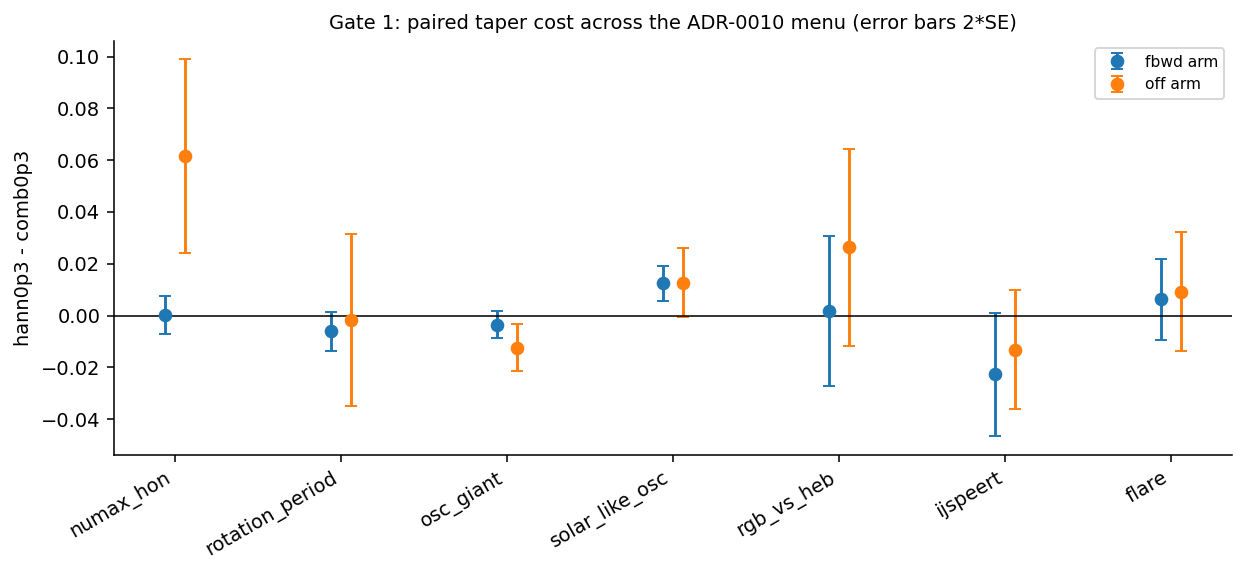

In [7]:
# 2.3 - Gate 1 paired deltas across the whole menu; negative = the taper costs that probe
g1all = gates[gates.recipe == f"{frozen_recipe}_minus_{baseline_recipe}"]
fig, ax = plt.subplots(figsize=(9, 4.2), dpi=140)
for i, arm in enumerate(["fbwd", "off"]):
    sel = g1all[g1all.arm == arm].set_index("task").reindex(adr0010_menu)
    ax.errorbar(np.arange(len(adr0010_menu)) + 0.12 * (i - 0.5), sel.gate1_delta, yerr=2 * sel.gate1_se,
                fmt="o", capsize=3, label=f"{arm} arm")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(adr0010_menu)))
ax.set_xticklabels(adr0010_menu, rotation=30, ha="right")
ax.set_ylabel(f"{frozen_recipe} - {baseline_recipe}")
ax.set_title("Gate 1: paired taper cost across the ADR-0010 menu (error bars 2*SE)", fontsize=10)
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

#### 2.1-2.3 - verdict: Gate 0 PASSES decisively, Gate 1 HOLDS. Q1 closes; branch A dies.

**Gate 0 (transfer): PASS, by 15 standard errors.** `hann0p3_fbwd` beats the six untrained inits on
`numax_hon` by **+0.376 +/- 0.025** R2. The frozen recipe transfers to the asteroseismic block, and the
project's downstream story no longer rests on exp05-arm numbers measured at a 60-epoch budget. This is
the first time the frozen recipe has been scored on this menu at all.

**Gate 1 (taper cost): HOLD, and not marginally.** Paired `hann0p3 - comb0p3` on the primary, fbwd arm:
**+0.0001 +/- 0.0037**. The replication probes agree - `osc_giant` -0.0035, `rgb_vs_heb` +0.0018,
`solar_like_osc` +0.0124, none beyond 2*SE. The taper's measured 13% reconstruction cost at 65-260 microHz
(F19) **does not reach the probes that read that band.**

That closes **Q1** and kills **branch A**: a frequency-weighted or multitaper aux term (Q12) would be
buying back a cost the downstream menu cannot see. It is also the sharpest instance yet of F20 - band-
resolved reconstruction fidelity does not predict probe score even when you go looking in the probe's
own band, with the probe that reads it, on the recipe that pays the cost.

**Q3 also closes, on measured evidence.** `lpsd0p3` holds 18.25 active units against the winner's 5.8
and ties it on the primary (0.8029 vs 0.8018, 4 seeds vs 6) while losing on `rotation_period` (0.664 vs
0.677). Capacity buys nothing downstream either. F25(b) inferred this from the v1 tasks; it is now
measured on the menu the extra capacity would most plausibly have helped.

---
## 3. CHK-2 - the taper relocated the impulse, it did not remove it

exp07 reported the window-edge defect closed (`hann0p3` edge_max 1.15x against `comb0p3`'s 31x) and F23
closed it as a probe cost. Reducing the per-position error profile **per seed** rather than
seed-averaged shows what that bought: a new impulse in the window **interior**, at the position where
the Hann weight is maximal. A symmetric Hann window is exactly zero at the endpoints, so the cheapest
place for the decoder to buy log-PSD power moves from p0 to the middle.

The spike's position wanders seed to seed (125 -> 143), which is why the seed-averaged profile smears
it to ~5x and why a fixed 125-143 band is the wrong estimator - the same ratio-of-means pathology F23
records for the edge, one level down.

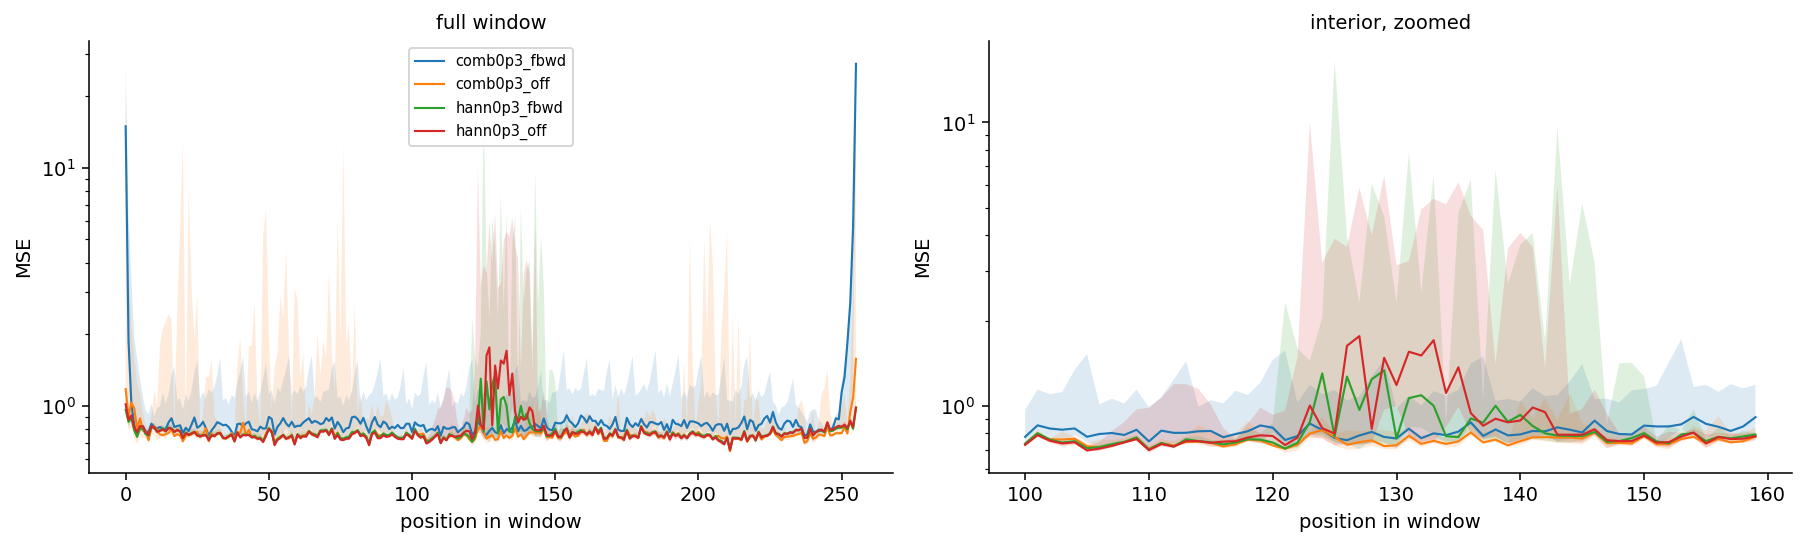

centre_ratio        edge_ratio         interior_mse       
                           mean    std       mean     std         mean    std
cell                                                                         
exp07_comb0p1_fbwd        1.154  0.107     18.337   7.190        0.784  0.045
exp07_comb0p1_off         1.093  0.049      2.995   2.443        0.747  0.008
exp07_comb0p3_fbwd        1.149  0.121     31.691   4.568        0.873  0.137
exp07_comb0p3_off         1.185  0.133     10.655  13.726        0.757  0.011
exp07_hann0p3_fbwd       11.773  5.320      1.309   0.034        0.759  0.007
exp07_hann0p3_off         8.782  2.349      1.368   0.048        0.754  0.009
exp07_lpsd0p1_fbwd        1.288  0.242      5.476   3.938        1.002  0.331
exp07_lpsd0p1_off         1.804  1.309      2.663   2.631        0.746  0.004
exp07_lpsd0p3_fbwd        1.131  0.059     41.900  13.580        0.834  0.086
exp07_lpsd0p3_off         2.081  1.552      2.431   1.566        0.769  0.025

In [8]:
# 3.1 - the per-position profile, per seed, both defects on one axis
prof = pd.read_parquet(required["profiles"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0), dpi=140)
for ax, (lo, hi, title) in zip(axes, [(0, 256, "full window"), (100, 160, "interior, zoomed")]):
    for cell, g in prof.groupby("cell"):
        band = g[(g.pos >= lo) & (g.pos < hi)].groupby("pos")["mse"]
        ax.plot(band.median().index, band.median().values, lw=1.1, label=cell.replace("exp07_", ""))
        ax.fill_between(band.min().index, band.min().values, band.max().values, alpha=0.15)
    ax.set_yscale("log"); ax.set_xlabel("position in window"); ax.set_ylabel("MSE")
    ax.set_title(title, fontsize=10); ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=7.5)
plt.tight_layout(); plt.show()

cells = pd.read_csv(required["centre_cells"])
display(cells.groupby("cell")[["centre_ratio", "edge_ratio", "interior_mse"]]
        .agg(["mean", "std"]).round(3))

In [9]:
# 3.2 - does it cost downstream score? per-star, within run, so no design axis is pooled over
centre_probe = pd.read_csv(required["centre_probe"])
per_run = (centre_probe.groupby(["cell", "task"])[["rho_centre_ratio", "rho_centre_excess"]]
           .agg(["mean", "std", "size"]).round(3))
display(per_run)

# The cell-level B4 analogue the handoff asked for, computed WITHIN arm and reported as such.
# Scored off exp07_aux_gap.csv because it covers all TEN exp07 cells (five recipes per arm), where the
# CHK-1 menu covers only the three recipes carried into the downstream fan.
aux_gap = pd.read_csv(required["aux_gap"])
aux_gap = aux_gap[(aux_gap.arm == "trained") & (aux_gap.pooling == "mean")].copy()
aux_gap["cell_arm"] = np.where(aux_gap.cell.str.endswith("fbwd"), "fbwd", "off")
aux_gap["recipe"] = aux_gap.cell.str.replace("exp07_", "", regex=False).str.rsplit("_", n=1).str[0]

print("\ncell-level within-arm rho(centre severity, cell mean probe score) - reported, NOT the verdict:")
print("(centre severity is bimodal across recipes - hann ~12, everything else ~1-2 - so at cell")
print(" granularity this is a two-group difference whose grouping variable is `recipe`: F21 one level down)")
for arm in ["fbwd", "off"]:
    sev = cells[cells.arm == arm].groupby("recipe")["centre_ratio"].mean()
    sc = aux_gap[aux_gap.cell_arm == arm].groupby("recipe")["pr_auc"].mean()
    common = sorted(set(sev.index) & set(sc.index))
    rho, p = stats.spearmanr(sev[common], sc[common])
    print(f"  {arm}: rho {rho:+.3f} (p {p:.3f}, n={len(common)} recipes: {', '.join(common)})")

rho_centre_ratio             rho_centre_excess            
                                         mean    std size              mean    std size
cell               task                                                                
exp07_comb0p3_fbwd eb                   0.012  0.045    6             0.353  0.142    6
                   pulsating            0.013  0.117    6            -0.335  0.092    6
exp07_comb0p3_off  eb                   0.097  0.065    6             0.409  0.046    6
                   pulsating            0.095  0.106    6            -0.114  0.047    6
exp07_hann0p3_fbwd eb                   0.041  0.040    6            -0.335  0.027    6
                   pulsating           -0.388  0.060    6             0.206  0.016    6
exp07_hann0p3_off  eb                  -0.033  0.042    6            -0.392  0.032    6
                   pulsating           -0.361  0.053    6            -0.157  0.066    6


cell-level within-arm rho(centre severity, cell mean probe score) - reported, NOT the verdict:
(centre severity is bimodal across recipes - hann ~12, everything else ~1-2 - so at cell
 granularity this is a two-group difference whose grouping variable is `recipe`: F21 one level down)
  fbwd: rho +0.900 (p 0.037, n=5 recipes: comb0p1, comb0p3, hann0p3, lpsd0p1, lpsd0p3)
  off: rho +0.900 (p 0.037, n=5 recipes: comb0p1, comb0p3, hann0p3, lpsd0p1, lpsd0p3)


In [10]:
# 3.3 - THE CONTROL THAT DECIDES 3.2: is a severity-vs-score correlation about the defect at all?
# Every ratio statistic divides by interior_mse, and interior_mse is a star property. If the denominator
# tracks the star's own amplitude/noise, then rho(ratio, score) measures the star, not the artifact --
# which is F23's lesson for the edge, one level down. Joined to the per-star noise/amp table.
from scipy.stats import spearmanr

centre_stars = pd.read_csv(required["centre_stars"])
noise_stars = pd.read_csv(required["edge_noise_stars"])[["cell", "seed", "tic_id", "noise", "amp", "snr"]]
joined = centre_stars.merge(noise_stars, on=["cell", "seed", "tic_id"], how="inner")
rows = []
for (cell, seed), g in joined.groupby(["cell", "seed"]):
    for var in ["centre_ratio", "centre_excess", "edge_ratio", "interior_mse", "centre_mse"]:
        rows.append({"cell": cell, "seed": seed, "var": var,
                     "rho_noise": spearmanr(g["noise"], g[var])[0],
                     "rho_amp": spearmanr(g["amp"], g[var])[0]})
conf = pd.DataFrame(rows)
print("rho(star noise / amplitude, severity statistic), mean over 6 seeds:")
display(conf.pivot_table(index="var", columns="cell", values=["rho_noise", "rho_amp"]).round(3))

rho(star noise / amplitude, severity statistic), mean over 6 seeds:


rho_amp                                                                 rho_noise                                       \
cell          exp07_comb0p3_fbwd exp07_comb0p3_off exp07_hann0p3_fbwd exp07_hann0p3_off exp07_comb0p3_fbwd exp07_comb0p3_off exp07_hann0p3_fbwd   
var                                                                                                                                               
centre_excess             -0.621            -0.652              0.648             0.617             -0.639            -0.684              0.853   
centre_mse                 0.412             0.616              0.682             0.664              0.325             0.575              0.864   
centre_ratio              -0.172            -0.177             -0.139            -0.137             -0.244            -0.235              0.254   
edge_ratio                -0.003            -0.331             -0.614            -0.621              0.375            -0.217             -0.618   
interior_mse               0.745             0.912              0.924             0.925              0.605             0.905              0.896   

                                 
cell          exp07_hann0p3_off  
var                              
centre_excess             0.828  
centre_mse                0.845  
centre_ratio              0.251  
edge_ratio               -0.635  
interior_mse              0.901

In [11]:
# 3.4 - the window-stitch comb, with the untrained control that says what kind of thing it is
stitch = pd.read_csv(required["stitch"])
display(stitch.groupby(["arm_kind", "cell"])["median"].agg(["mean", "std", "size"]).round(2))

mean   std  size
arm_kind  cell                                 
input     input                1.51   NaN     1
trained   exp07_comb0p3_fbwd  20.43  3.56     6
          exp07_comb0p3_off   22.34  2.38     6
          exp07_hann0p3_fbwd  26.64  2.40     6
          exp07_hann0p3_off   22.05  1.61     6
untrained untrained           31.89  7.06     6

#### 3.1-3.4 - verdict: the defect moved, and it still costs nothing downstream

**The defect moved, it did not close.** At 6 seeds, `hann0p3_fbwd` carries a centre impulse of
**11.8 +/- 5.3x** the interior level (off arm 8.8 +/- 2.3x) while its edge sits at 1.31x; `comb0p3_fbwd`
is the mirror image, 31.7x at the boundary and 1.15x in the middle. Both are single-position impulses
buying log-PSD power. F23's "the edge is closed as a lever" and the README's "edge exactly clean" are
true as stated and misleading as read; both are qualified.

**But the apparent probe cost in 3.2 is a ratio artifact, and 3.3 proves it.** Within the hann cells,
rho(centre_ratio, pulsating score) = **-0.39 +/- 0.06** - which reads as a real cost until you run the
same correlation with `edge_ratio` **in the same cells, where there is no edge defect** (1.31x): it
returns **-0.39** as well. A statistic that reports the same effect size for a defect that is present
and one that is absent is not measuring the defect.

3.3 names the mechanism: `interior_mse`, the shared denominator of every ratio, tracks the star's own
amplitude at **rho 0.92** and its noise at **rho 0.90**. The ratio is a star property wearing an
artifact's name. This is F23's finding reproduced exactly one level down, and the third time in this
project a ratio statistic has pointed the wrong way (F15, F23, here). The absolute form disagrees with
itself across arms (`centre_excess` vs pulsating: +0.21 fbwd, -0.16 off), which is what no effect looks
like. **No evidence the centre artifact costs downstream score; P1 is not exp08's problem.**

3.3 does surface a real mechanistic parallel: `centre_excess` correlates with star noise at **+0.85** in
the hann cells, just as `comb0p3`'s *edge* excess did at +0.90 (F23). The purchase scales with the star's
broadband power in both recipes - the same transaction, relocated.

**The stitch comb is architectural, not learned.** At 6 seeds the **untrained** arm combs at **31.9 +/-
7.1**, harder than any trained cell (20.4-26.6), against an input at **1.51**. So the comb is a
consequence of decoding windows independently, training *reduces* it, and no aux-term redesign touches
it. It is also invariant to the taper by construction - an impulse at position 0 and one at position 130
produce the same comb frequencies and differ only in phase. Recorded as **paper hygiene** (the number is
already outside the project in the Yue Ma update and needed a reproducible home), explicitly **not** as
evidence of a probe cost: probes read mu and never see a reconstruction.

*Scope.* The per-star join covers **eb and pulsating only** - `exp07_diag_star_scores.parquet` never
dumped rotation or transit per-star predictions. That is an input limitation, not a filter.

---
## 4. CHK-3 - what channel do the probes read?

exp06 measured that star-level mu is dominated by one direction (PC1 = 93% of variance, R2 0.97 against
amplitude scalars alone) and that residualizing against an **amplitude** basis costs eb and rotation but
not pulsating. That basis was deliberately periodicity-free, so frequency content survived by
construction and it cannot speak to the fusion claim.

Two nested bases make the increment readable, and the second is the one nobody had run:

- `B_amp` - scale and roughness only (four scalars), cannot remove periodicity
- `B_full` - all 25 T'DA-style engineered features, periodogram structure included

`probe(mu perp B_full)` is what the ML4PS **fusion claim** - "SSL carries something engineered features
do not" - actually rests on.

In [12]:
# 4.1 - the five readouts: where the probe-carrying signal lives between mu and the engineered basis
channel = pd.read_csv(required["channel"])
order = ["mu", "mu_resid_amp", "mu_resid_full", "features_only", "features_plus_mu"]
for arm_label, sel in [("fbwd", channel[channel.cell.str.endswith("fbwd")]),
                       ("off", channel[channel.cell.str.endswith("off")])]:
    print(f"\n--- {arm_label} arm (mean over recipes and seeds)")
    display(sel.pivot_table(index="readout", columns="task", values="pr_auc").reindex(order).round(4))


--- fbwd arm (mean over recipes and seeds)


task,eb,pulsating,rotation,transit
readout,,,,
mu,0.7754,0.7959,0.5614,0.1451
mu_resid_amp,0.5941,0.7954,0.4359,0.1647
mu_resid_full,0.3153,0.3604,0.2489,0.1247
features_only,0.7416,0.7885,0.5399,0.1901
features_plus_mu,0.7775,0.8356,0.5527,0.2152



--- off arm (mean over recipes and seeds)


task,eb,pulsating,rotation,transit
readout,,,,
mu,0.7354,0.7928,0.5354,0.1260
mu_resid_amp,0.5112,0.7781,0.3850,0.1359
mu_resid_full,0.2102,0.2984,0.1878,0.1124
features_only,0.7416,0.7885,0.5399,0.1901
features_plus_mu,0.7503,0.8301,0.5355,0.1925


In [13]:
# 4.2 - both directions between mu and the engineered basis, held-out R2
featmap = pd.read_csv(required["featmap"])
m2f = featmap[featmap.direction == "mu_to_feature"]
top = (m2f.groupby("target")[["r2_ridge", "r2_gbm"]].mean()
       .sort_values("r2_gbm", ascending=False).round(3))
print("mu -> engineered feature, best-recovered first (how much of each feature mu re-encodes):")
display(top.head(12))
print("\nengineered basis -> mu dimension (how much of the latent the features reconstruct):")
display(featmap[featmap.direction == "feature_to_mu"]
        .groupby("cell")[["r2_ridge", "r2_gbm"]].mean().round(3))

mu -> engineered feature, best-recovered first (how much of each feature mu re-encodes):


,r2_ridge,r2_gbm
target,,
p2p_scatter_ratio,0.984,0.995
spectral_centroid_log10,0.978,0.992
psd_band7,0.977,0.988
spectral_entropy,0.964,0.982
psd_band6,0.962,0.975
psd_band5,0.912,0.937
psd_band4,0.851,0.891
depth_5_95,0.801,0.824
psd_band2,0.586,0.789



engineered basis -> mu dimension (how much of the latent the features reconstruct):


,r2_ridge,r2_gbm
cell,,
exp07_comb0p3_fbwd,0.482,0.606
exp07_comb0p3_off,0.255,0.220
exp07_hann0p3_fbwd,0.508,0.621
exp07_hann0p3_off,0.355,0.328


#### 4.1-4.2 - verdict: mu is NOT just a re-encoding, and the fusion claim now has a number

I pre-registered the expectation that `probe(mu perp B_full)` would collapse toward the base rate. **It
does not.** Projecting out all 25 engineered features leaves a latent that still probes at **2.1-3.4x
base rate** (fbwd arm: eb 0.315 vs base 0.097, pulsating 0.360 vs 0.107, rotation 0.249 vs 0.089,
transit 0.125 vs 0.060). So mu carries structure the T'DA-style feature basis does not.

**The fusion cell is the headline, and it is dynamics-specific.** `features_plus_mu` beats
`features_only` on all four tasks in the fbwd arm, every one beyond 2*SE (paired over 2 recipes x 6
seeds): eb **+0.036 +/- 0.002**, pulsating **+0.047 +/- 0.004**, rotation **+0.013 +/- 0.005**, transit
**+0.025 +/- 0.004**. In the **dyn-off** arm only pulsating (+0.042) and eb (+0.009) survive; rotation
(-0.004) and transit (+0.003) do not.

Two consequences. The ML4PS **fusion claim stops being an assertion** - "SSL carries something engineered
features do not" is now a measured, paired, seed-resolved number on the frozen recipe. And the
complementarity is **bought by the dynamics term**, which hands section 5 its question already half
answered.

**The pre-registered tie-break does NOT fire.** CHK-3 was to outrank Gate 1 only if mu turned out to be a
re-encoding; it is not. So the branch falls through to Gate 0 (PASS) and Gate 1 (HOLD).

Secondary reading, consistent with exp06: `mu_resid_amp` barely touches pulsating (0.796 -> 0.795) while
it costs eb (0.775 -> 0.594) and rotation (0.561 -> 0.436). Pulsating is not an amplitude effect; eb and
rotation substantially are.

---
## 5. CHK-4 - what do the one-to-three extra active units carry?

At ep100 the dynamics arm holds barely more latent capacity than its own dyn-off arm (`hann0p3` 5.8 vs
5.0) and still wins every task, while a cell holding 18 units scores mid-table (F25). So the win is not
capacity. Three hypotheses: **(a)** new content, **(b)** the same content in a more linearly readable
direction, **(c)** a scale change the probe's `StandardScaler` exploits.

The obvious estimator cannot separate them: cross-recipe, linearly predicting one cell's mu from
another's leaves `resid_var_frac` = 0.005 and collapses every probe, and with 5-8 active dims sharing
one dominant amplitude direction that is near-guaranteed for any pair. So four measurements instead,
all **within recipe** - `hann_fbwd` vs `hann_off`, never `hann_fbwd` vs `comb_off`, which would span
both design axes at once.

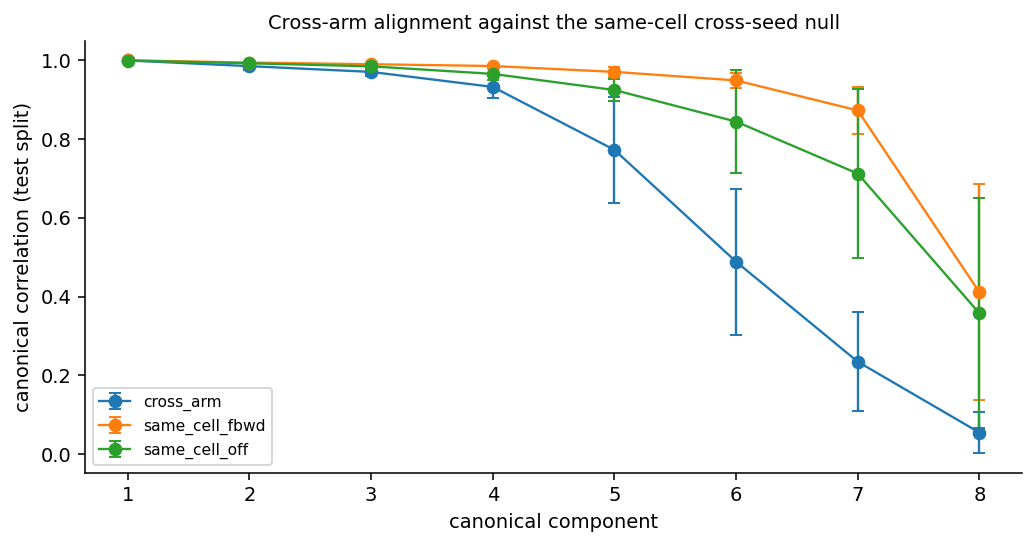

pair,cross_arm,same_cell_fbwd,same_cell_off
component,,,
1,0.999,1.000,0.999
2,0.985,0.994,0.992
3,0.970,0.990,0.985
4,0.932,0.985,0.965
5,0.772,0.970,0.924
6,0.488,0.949,0.844
7,0.235,0.873,0.712
8,0.055,0.411,0.358


In [14]:
# 5.1 - CCA cross-arm, against the within-cell cross-seed pair as the null distribution.
# Without that null a principal angle is uninterpretable: two seeds of the SAME cell are not identical.
cca = pd.read_csv(required["cca"])
fig, ax = plt.subplots(figsize=(7.5, 4.0), dpi=140)
for pair, g in cca.groupby("pair"):
    m = g.groupby("component")["cancorr"].agg(["mean", "std"])
    ax.errorbar(m.index, m["mean"], yerr=m["std"], fmt="o-", capsize=3, lw=1.2, label=pair)
ax.set_xlabel("canonical component"); ax.set_ylabel("canonical correlation (test split)")
ax.set_title("Cross-arm alignment against the same-cell cross-seed null", fontsize=10)
ax.legend(fontsize=8); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
display(cca.pivot_table(index="component", columns="pair", values="cancorr").round(3))

In [15]:
# 5.2 - the asymmetric residual probe. Both directions are low; the DIFFERENCE is the signal.
residual = pd.read_csv(required["residual"])
display(residual.pivot_table(index=["recipe", "direction"], columns="task", values="pr_auc").round(4))
print("\nresidual variance fraction (how much of the target mu survives the projection):")
display(residual.groupby(["recipe", "direction"])["resid_var_frac"].mean().round(5))

asym = (residual.pivot_table(index=["recipe", "task"], columns="direction", values="pr_auc")
        .assign(asymmetry=lambda d: d["fbwd_perp_off"] - d["off_perp_fbwd"]).round(4))
print("\nasymmetry > 0 => the dynamics arm holds content the dyn-off arm does not (hypothesis a):")
display(asym)

task                       eb  pulsating  rotation  transit
recipe  direction                                          
comb0p3 fbwd_perp_off  0.3031     0.2850    0.2435   0.0853
        off_perp_fbwd  0.1537     0.1953    0.1776   0.0767
hann0p3 fbwd_perp_off  0.2928     0.2852    0.2280   0.0820
        off_perp_fbwd  0.1506     0.1610    0.1432   0.0757


residual variance fraction (how much of the target mu survives the projection):


recipe   direction    
comb0p3  fbwd_perp_off    0.02381
         off_perp_fbwd    0.00247
hann0p3  fbwd_perp_off    0.02205
         off_perp_fbwd    0.00231
Name: resid_var_frac, dtype: float64


asymmetry > 0 => the dynamics arm holds content the dyn-off arm does not (hypothesis a):


direction          fbwd_perp_off  off_perp_fbwd  asymmetry
recipe  task                                              
comb0p3 eb                0.3031         0.1537     0.1494
        pulsating         0.2850         0.1953     0.0898
        rotation          0.2435         0.1776     0.0659
        transit           0.0853         0.0767     0.0086
hann0p3 eb                0.2928         0.1506     0.1422
        pulsating         0.2852         0.1610     0.1242
        rotation          0.2280         0.1432     0.0848
        transit           0.0820         0.0757     0.0063

In [16]:
# 5.3 - hypothesis (c) head on: is the benefit something a rescaling could have supplied?
scaling = pd.read_csv(required["scaling"])
display(scaling.pivot_table(index=["recipe", "arm", "readout"], columns="task", values="pr_auc").round(4))
# mu_whitened is a NULL control: a scaled linear probe is invariant to per-dimension rescaling, so it
# must reproduce mu_active exactly. If it does not, the probe pipeline is not what the tables assume.
chk = scaling.pivot_table(index=["recipe", "arm", "task"], columns="readout", values="pr_auc")
# A scaled linear probe is invariant to per-dimension rescaling in EXACT arithmetic, but lbfgs stops at
# a tolerance, so the two differ by solver noise rather than by zero. 5e-3 is the documented bound:
# anything larger would mean the rescaling changed the fit, not just the path taken to it.
null_gap = (chk["mu_whitened"] - chk["mu_active"]).abs()
print(f"\nnull control |mu_whitened - mu_active|: max {null_gap.max():.2e}, median {null_gap.median():.2e}")
print("holds within solver tolerance:", bool(null_gap.max() < 5e-3))

task                          eb  pulsating  rotation  transit
recipe  arm  readout                                          
comb0p3 fbwd mu_active    0.7798     0.7873    0.5636   0.1461
             mu_unscaled  0.7624     0.7765    0.5506   0.1670
             mu_whitened  0.7796     0.7873    0.5632   0.1459
        off  mu_active    0.7330     0.7748    0.5348   0.1165
             mu_unscaled  0.6147     0.5659    0.4251   0.1313
             mu_whitened  0.7330     0.7747    0.5347   0.1165
hann0p3 fbwd mu_active    0.7711     0.8045    0.5593   0.1441
             mu_unscaled  0.7673     0.7781    0.5552   0.1590
             mu_whitened  0.7711     0.8054    0.5592   0.1441
        off  mu_active    0.7378     0.8109    0.5360   0.1356
             mu_unscaled  0.6378     0.5817    0.4776   0.1379
             mu_whitened  0.7379     0.8112    0.5360   0.1355


null control |mu_whitened - mu_active|: max 8.78e-04, median 6.48e-05
holds within solver tolerance: True


#### 5.1-5.3 - verdict: hypothesis (a). The dynamics term adds content, and all three tests agree.

**CCA (5.1) - private directions exist.** Read against the same-cell cross-seed null, not against 1.0.
The cross-arm curve tracks the null for the first four components and then separates decisively:

| component | cross-arm | same-cell fbwd null | same-cell off null |
|---|---|---|---|
| 4 | 0.932 | 0.985 | 0.965 |
| 5 | **0.772** | 0.970 | 0.924 |
| 6 | **0.489** | 0.949 | 0.844 |
| 7 | **0.235** | 0.873 | 0.712 |

Two seeds of the *same* cell agree to 0.87 on component 7; the two arms agree to 0.24. The dynamics arm
holds directions that seed-to-seed variation does not explain.

**Asymmetry (5.2) - and it is the dynamics arm that holds them.** `fbwd perp off` retains **2.2-2.4%** of
its variance after the other arm is projected out; `off perp fbwd` retains **0.23-0.25%** - a **10x**
asymmetry. The residual probes accordingly (eb 0.30 vs 0.15, pulsating 0.285 vs 0.18, rotation 0.24 vs
0.15), and the paired asymmetry clears 2*SE on every task: eb **+0.146 +/- 0.010**, pulsating **+0.107
+/- 0.009**, rotation **+0.075 +/- 0.010**, transit **+0.008 +/- 0.002**.

**Scaling (5.3) - hypothesis (c) is refuted, in the strong direction.** Without the probe's
`StandardScaler` the fbwd-off gap does not shrink, it **inflates**: pulsating 0.003 -> **0.204**, eb 0.040
-> 0.139, rotation 0.026 -> 0.102. The dyn-off arm is the one that depends on the scaler (its pulsating
score falls 0.793 -> 0.574 without it). So the scaler *compresses* the dynamics advantage rather than
manufacturing it, and every gap this project reports is, if anything, conservative.

**Q11 closes as (a): new content.** The paper can now say what the dynamics term added, not just that it
helped - and section 4 says the same thing from the other side, since the fbwd arm's mu is the one that
adds to the engineered-feature basis on all four tasks while the dyn-off arm's does not.

---
## 6. Where this leaves exp08: **branch B**

Applying the pre-registered rule in its pre-registered order:

1. **CHK-3 tie-break: does not fire.** mu is not a re-encoding of the engineered basis - it probes at
   2.1-3.4x base rate with all 25 features projected out, and it *adds* to them on all four tasks. So
   CHK-3 does not override Gate 1.
2. **Gate 0: PASS** (+0.376 +/- 0.025 on `numax_hon`). The frozen recipe transfers.
3. **Gate 1: HOLD** (+0.0001 +/- 0.0037). The taper is free where it matters.

**-> branch B.** The aux term is not exp08's problem: Q12 (multitaper / frequency-weighted aux) would buy
back a cost the downstream menu cannot detect, and the centre artifact it would also address is not
costing probe score either. **exp08 is Q4** - the smoothness ablation: replace the GRU rollout with a
two-step smoothness penalty on mu and no learned dynamics, 4 seeds paired on the frozen recipe. That is
the sharpest objection a reviewer can raise about the "world model" framing, and sections 4 and 5 have
just raised its stakes considerably: the dynamics term is now the thing carrying content that engineered
features do not have, so what exactly it is has become the paper's central question rather than a
caveat.

### What closed

| question | verdict |
|---|---|
| **Q1** taper cost downstream | **CLOSED - no cost.** Gate 1 +0.0001 +/- 0.0037 on the primary; three replication probes agree. The 13% pulsator-band reconstruction penalty does not reach the probes. |
| **Q2** what channel probes read | **CLOSED - not a re-encoding.** mu perp B_full probes at 2.1-3.4x base rate; fusion adds +0.013..+0.047 on all four tasks (fbwd), > 2*SE. |
| **Q3** is the collapse binding | **CLOSED - capacity is not a lever.** `lpsd0p3` (18.25 units) ties the winner (5.8) on `numax_hon` and loses on `rotation_period`, now measured on the downstream menu. |
| **Q8** selection floor | **CLOSED - no pathology.** F18 retracted; the guard was always in the loop. |
| **Q11** what the extra dyn units carry | **CLOSED - (a) new content.** CCA tail below the seed null, 10x residual-variance asymmetry, and the scaler *compresses* rather than creates the gap. |
| **P1** centre/edge artifact | **Not a probe cost.** The -0.39 correlation is a ratio artifact; `edge_ratio` returns the same value where no defect exists. |

### Still open, and now more interesting

- **Q4** is exp08.
- **Q6** (MIL for the tables) is unchanged and still blocked on a decision, not a measurement.
- **Q9** (v1 rotation labels confounded) is untouched and still report-level.
- The weight-0.1 dyn-off cells sitting near the untrained floor now have **no explanation** (F18's was
  wrong). Flagged, not chased before Aug 15.